**Professor:** Christian Mata Miquel

**Subject:** Data Analysis & Pattern Recognition

**Module:** Exploratory Data Analysis

# **S2. DATA VISUALIZATION**

**PRACTICE EXERCISES**

This notebook contains 3 exercises to practice pandas data handling and seaborn/matplotlib visualization. To keep things simple and avoid uploading files, all exercises use datasets built into seaborn (`sns.load_dataset(...)`), which download automatically the first time you run them.

Complete the code in the cells marked with `# YOUR CODE HERE`.


---

## Exercise 1: Handling data and missing values — Penguins dataset

Load the built-in `penguins` dataset from seaborn:

```python
import seaborn as sns
penguins = sns.load_dataset('penguins')
```

Answer the following questions:

a) How many rows and columns does the dataset have? (`.shape`)

b) How many observations have a missing value in the `body_mass_g` column? (use `.isna()`, as seen with the Titanic `Age` column)

c) Create a new dataframe `penguins_filled` where the missing values of `body_mass_g` are replaced with the **mean** of the column (`.fillna()`).

d) Using `.groupby()`, compute the mean `body_mass_g` and `flipper_length_mm` **per species** (`species` column).

e) Filter the dataset to show only penguins of species `"Gentoo"` with `body_mass_g` greater than 5000 (combine two conditions with `&`, as done with the Titanic `Humans`/`Robots` example).

In [1]:
import seaborn as sns
import pandas as pd

penguins = sns.load_dataset('penguins')
penguins.head()

print(penguins.shape)
print(penguins.loc[penguins["body_mass_g"].isna()].shape)

penguins_filled = penguins.fillna(penguins["body_mass_g"].mean())

body_mass_g = penguins_filled.groupby(by="species")
body_mass_g_mean = body_mass_g["body_mass_g"].mean()
print(body_mass_g_mean)
flipper_length_mm= penguins_filled.groupby(by="species")
flipper_length_mm_mean = flipper_length_mm["flipper_length_mm"].mean()
print(flipper_length_mm_mean)

gentoo_heavy = penguins_filled.loc[(penguins_filled["species"] == "Gentoo") & (penguins_filled["body_mass_g"] > 5000)]

(344, 7)
(2, 7)
species
Adelie       3703.958910
Chinstrap    3733.088235
Gentoo       5068.965761
Name: body_mass_g, dtype: float64
species
Adelie       216.347068
Chinstrap    195.823529
Gentoo       249.320600
Name: flipper_length_mm, dtype: float64


---

## Exercise 2: Basic and grouped plots — Tips dataset

Load the built-in `tips` dataset from seaborn:

```python
tips = sns.load_dataset('tips')
```

This dataset contains information about restaurant bills: `total_bill`, `tip`, `sex`, `smoker`, `day`, `time`, `size`.

Create the following plots (remember to set `figsize`, add a title with `.set_title()`, and call `plt.show()`):

a) A **scatter plot** of `total_bill` (x-axis) vs `tip` (y-axis).

b) The same scatter plot, but colored by `smoker` status using the `hue` parameter (like the `origin` example with cars).

c) A **linear model plot** (`sns.lmplot`) of `total_bill` vs `tip`, separated by `time` (Lunch/Dinner) using `hue`.

d) A **bar plot** showing the average `tip` for each `day` of the week.

e) A **histogram** (`sns.distplot` or `sns.histplot`) of the `total_bill` column, and mark the **mean** value with a vertical dashed line (`plt.axvline`).

/var/folders/kr/qkxcqsy101x84gw5gn41ymwc0000gn/T/ipykernel_5769/3683012220.py:19: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(x=tips["total_bill"].values, bins=100)


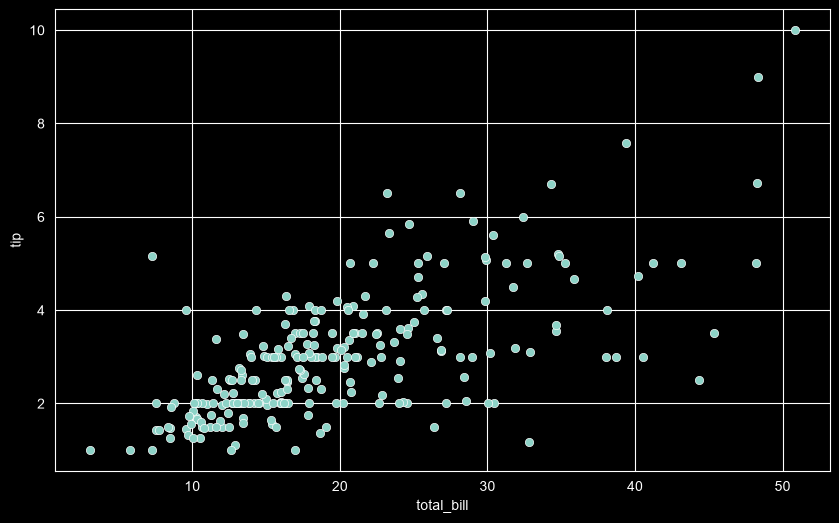

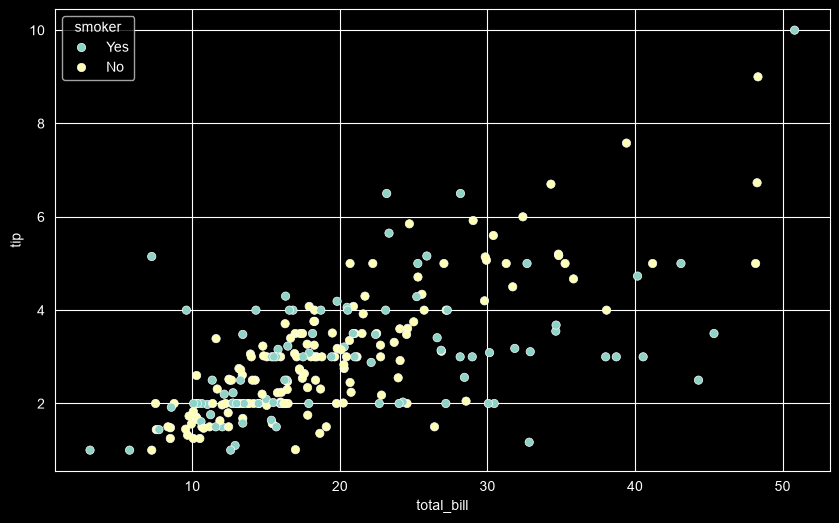

<Figure size 1000x600 with 0 Axes>

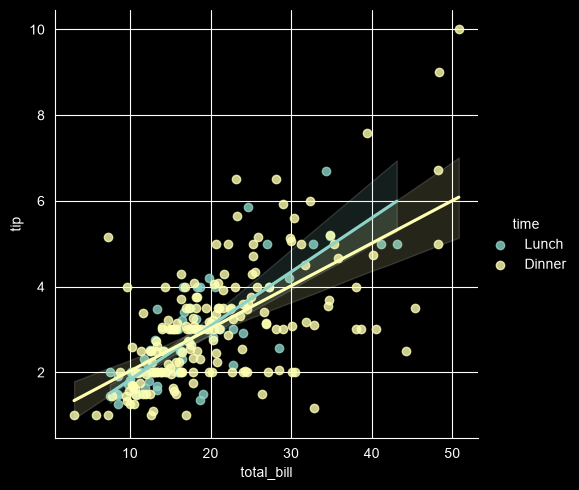

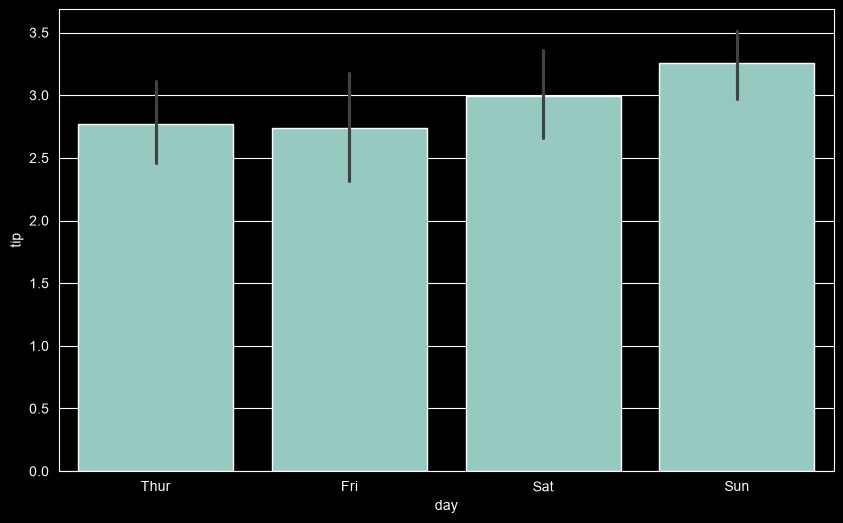

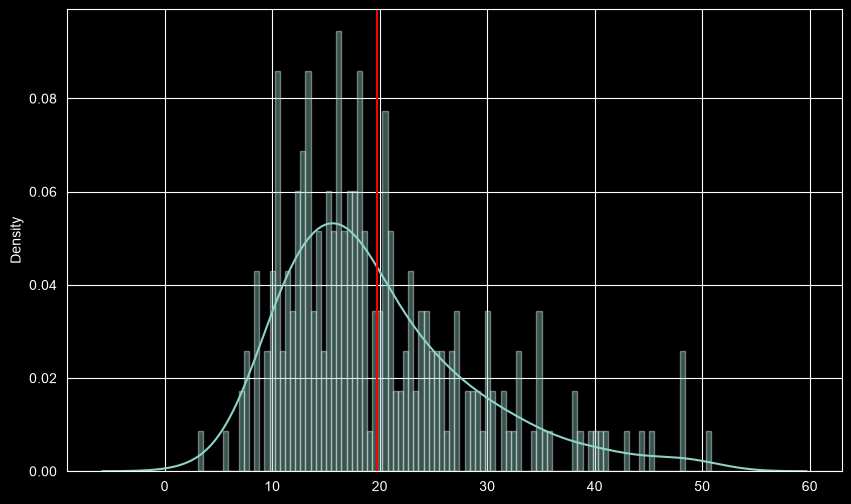

In [2]:
import matplotlib.pyplot as plt

tips = sns.load_dataset('tips')
tips.head()

fig = plt.figure(figsize=(10,6))
ax = sns.scatterplot(x="total_bill", y="tip", data=tips)

fig = plt.figure(figsize=(10,6))
ax = sns.scatterplot(x="total_bill", y="tip", hue="smoker", data=tips)

fig = plt.figure(figsize=(10,6))
ax = sns.lmplot(x="total_bill", y="tip", hue="time", data=tips)

fig = plt.figure(figsize=(10,6))
ax = sns.barplot(x="day", y="tip", data=tips)

fig = plt.figure(figsize=(10,6))
ax = sns.distplot(x=tips["total_bill"].values, bins=100)
mean = tips["total_bill"].mean()
plt.axvline(mean, color="r")

plt.show()


---

## Exercise 3: Distributions and multidimensional relationships — Diamonds dataset

Load the built-in `diamonds` dataset from seaborn (it's large, so we take a random sample of 1000 rows to keep the plots fast):

```python
diamonds = sns.load_dataset('diamonds').sample(1000, random_state=42)
```

This dataset contains information about diamonds: `carat`, `cut`, `color`, `clarity`, `depth`, `table`, `price`, and dimensions `x`, `y`, `z`.

a) Get a statistical summary of the numeric variables with `.describe()`.

b) Create a **histogram** of the `price` variable and mark the mean (dashed line) and the mean ± one standard deviation (two more vertical lines), as done with the `weight` variable of the cars dataset.

c) Create a **joint distribution plot** (`sns.jointplot`) between `carat` and `price`.

d) Create a **pairplot** (`sns.pairplot`) using only the numeric columns `carat`, `depth`, `table`, `price`, colored by the `cut` category with `hue`.

e) Based on the plots above, write one sentence (in a markdown cell or as a Python comment) describing the relationship you observe between `carat` and `price`.

/var/folders/kr/qkxcqsy101x84gw5gn41ymwc0000gn/T/ipykernel_5769/2483812103.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(x=diamonds["price"].values, bins=100)


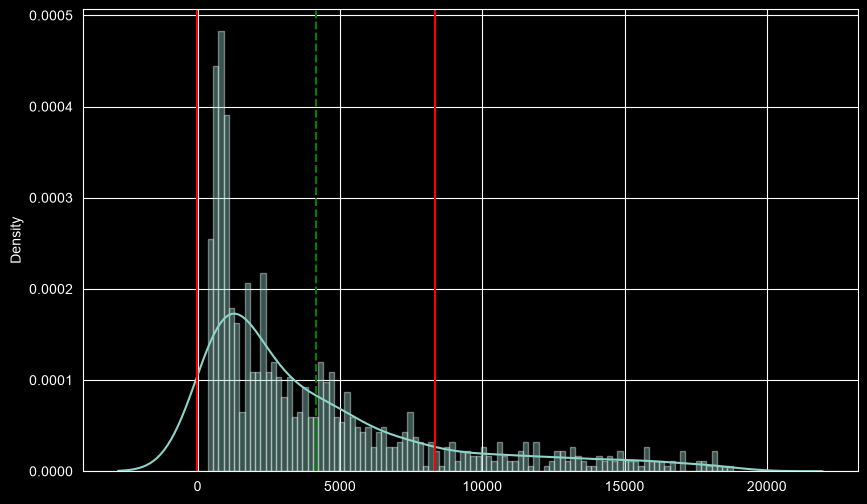

<Figure size 1000x600 with 0 Axes>

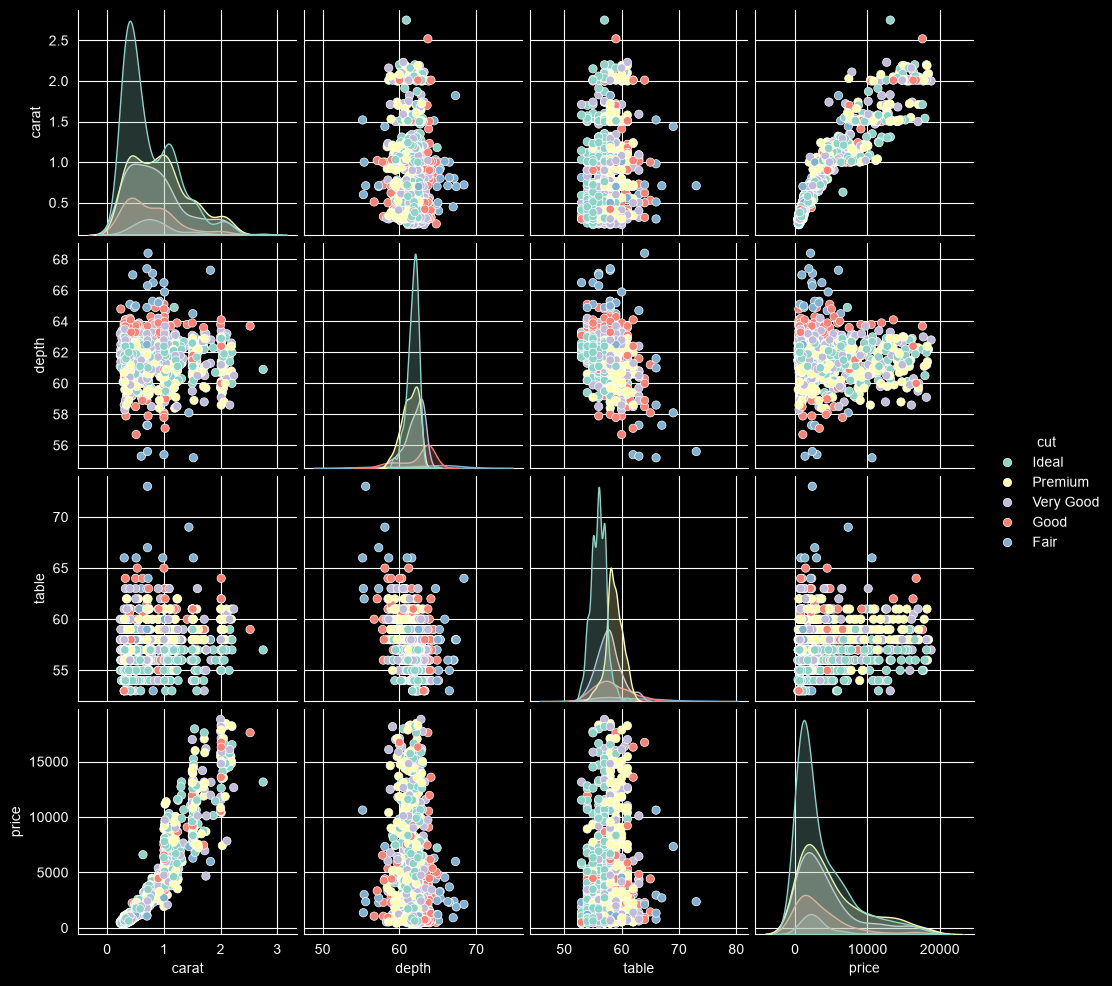

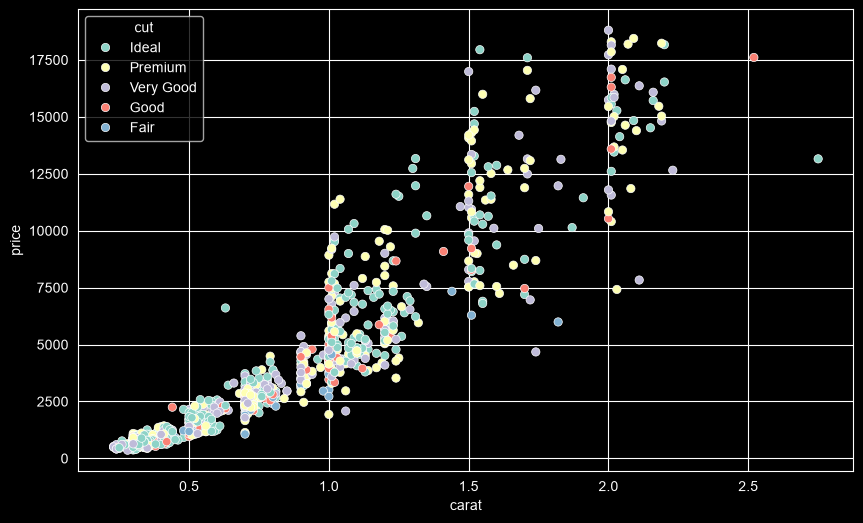

In [3]:
diamonds = sns.load_dataset('diamonds').sample(1000, random_state=42)
diamonds.head()

diamonds.describe()

mean = diamonds["price"].mean()
std = diamonds["price"].std()
fig = plt.figure(figsize=(10,6))
ax = sns.distplot(x=diamonds["price"].values, bins=100)
plt.axvline(mean, color="g", linestyle="dashed")
plt.axvline(mean - std, color="r")
plt.axvline(mean + std, color="r")

fig = plt.figure(figsize=(10,6))
ax = sns.pairplot(diamonds, vars=["carat", "depth", "table", "price"], hue="cut")

fig = plt.figure(figsize=(10,6))
ax = sns.scatterplot(x="carat", y="price", hue="cut", data=diamonds)

plt.show()

> if the carat increases, the price increases too.